Step 1 — Load and combine both files

In [3]:
# pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [6]:
# Load both files and combine
df1 = pd.read_csv('D:\Fraudulent_E-Commerce_Transaction_Data.csv')  # Fixed: matching single quotes
df2 = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data_2.csv')
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)        # ~1.5 million rows, 16 columns
print(df.head())
print(df.isnull().sum())  # no nulls — clean datase

(1496586, 16)
                         Transaction ID                           Customer ID  \
0  15d2e414-8735-46fc-9e02-80b472b2580f  d1b87f62-51b2-493b-ad6a-77e0fe13e785   
1  0bfee1a0-6d5e-40da-a446-d04e73b1b177  37de64d5-e901-4a56-9ea0-af0c24c069cf   
2  e588eef4-b754-468e-9d90-d0e0abfc1af0  1bac88d6-4b22-409a-a06b-425119c57225   
3  4de46e52-60c3-49d9-be39-636681009789  2357c76e-9253-4ceb-b44e-ef4b71cb7d4d   
4  074a76de-fe2d-443e-a00c-f044cdb68e21  45071bc5-9588-43ea-8093-023caec8ea1c   

   Transaction Amount     Transaction Date Payment Method Product Category  \
0               58.09  2024-02-20 05:58:41  bank transfer      electronics   
1              389.96  2024-02-25 08:09:45     debit card      electronics   
2              134.19  2024-03-18 03:42:55         PayPal    home & garden   
3              226.17  2024-03-16 20:41:31  bank transfer         clothing   
4              121.53  2024-01-15 05:08:17  bank transfer         clothing   

   Quantity  Customer Age Cust

In [7]:
print(df['Is Fraudulent'].value_counts())
print(df['Is Fraudulent'].value_counts(normalize=True).round(3))

Is Fraudulent
0    1421526
1      75060
Name: count, dtype: int64
Is Fraudulent
0    0.95
1    0.05
Name: proportion, dtype: float64


In [9]:
#Step 2 — Spot the data quality issue

#Before touching any model, always explore your data carefully.

print(df['Customer Age'].describe())
print('Negative ages:', len(df[df['Customer Age'] < 0]))
print('Under 18:', len(df[df['Customer Age'] < 18]))

count    1.496586e+06
mean     3.451284e+01
std      1.000323e+01
min     -1.600000e+01
25%      2.800000e+01
50%      3.500000e+01
75%      4.100000e+01
max      8.600000e+01
Name: Customer Age, dtype: float64
Negative ages: 259
Under 18: 66526


In [10]:
df=df[df['Customer Age'] >=18]
print(df.shape)

(1430060, 16)


Step 3 — Explore what drives fraud

<function matplotlib.pyplot.show(close=None, block=None)>

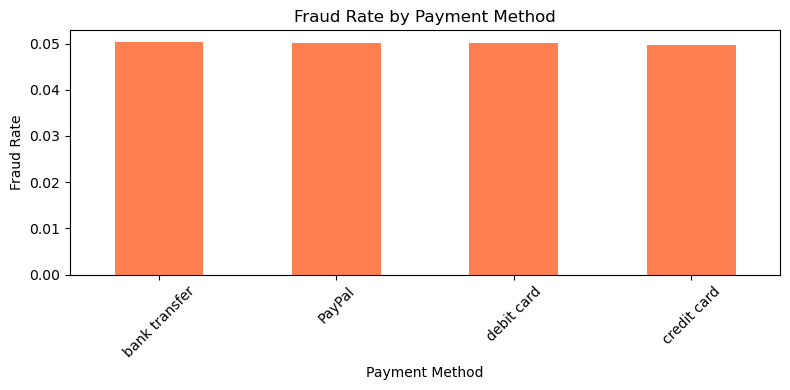

In [12]:
# Fraud rate by payment method
fraud_by_payment = df.groupby('Payment Method')['Is Fraudulent'].mean().sort_values(ascending=False)
fraud_by_payment.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Fraud Rate by Payment Method')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

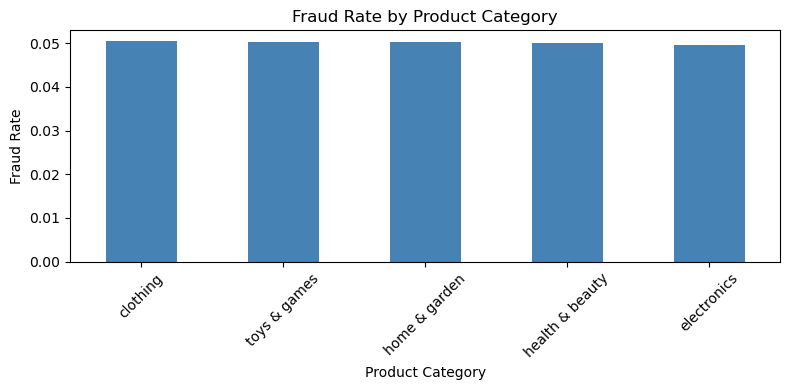

In [13]:
# Fraud rate by product category
fraud_by_category = df.groupby('Product Category')['Is Fraudulent'].mean().sort_values(ascending=False)
fraud_by_category.plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.title('Fraud Rate by Product Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

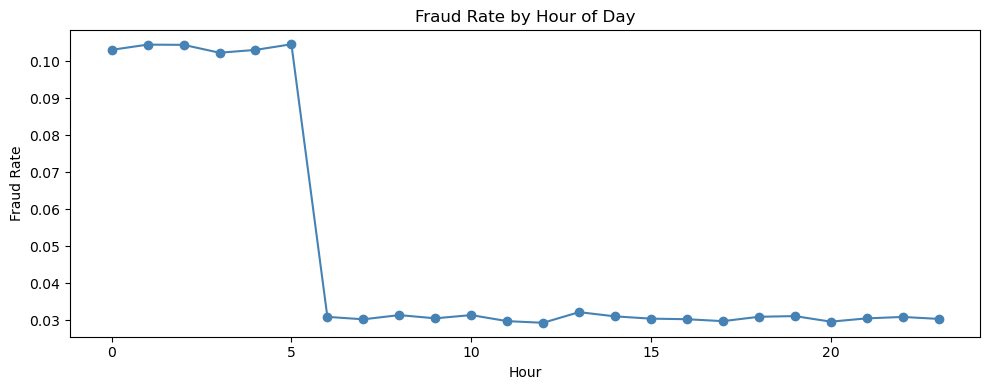

In [14]:
# Fraud rate by hour of day
fraud_by_hour = df.groupby('Transaction Hour')['Is Fraudulent'].mean()
fraud_by_hour.plot(kind='line', color='steelblue', figsize=(10, 4), marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

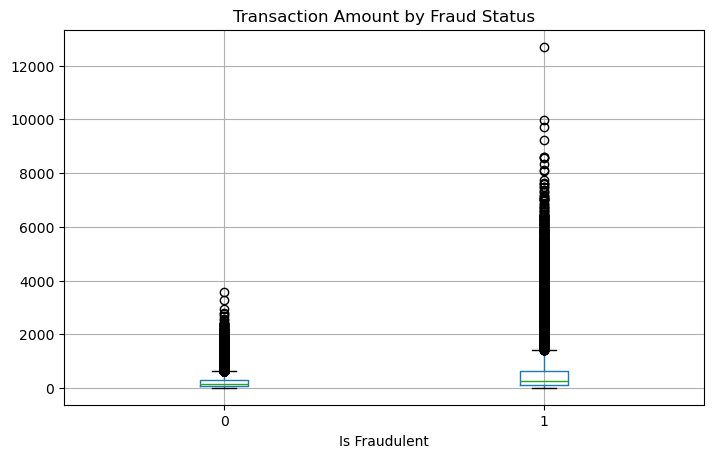

In [15]:
# Transaction amount — fraud vs legitimate
df.boxplot(column='Transaction Amount', by='Is Fraudulent', figsize=(8, 5))
plt.title('Transaction Amount by Fraud Status')
plt.suptitle('')
plt.show()

In [16]:
# Drop columns not useful for modelling — IDs and addresses
drop_cols = ['Transaction ID', 'Customer ID', 'IP Address',
             'Shipping Address', 'Billing Address', 'Customer Location',
             'Transaction Date']
df = df.drop(columns=drop_cols, errors='ignore')

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['Payment Method', 'Product Category', 'Device Used'], drop_first=True)

print(df.shape)
print(df.head())

(1430060, 15)
   Transaction Amount  Quantity  Customer Age  Is Fraudulent  \
1              389.96         2            40              0   
2              134.19         2            22              0   
3              226.17         5            31              0   
4              121.53         2            51              0   
5              166.41         2            34              0   

   Account Age Days  Transaction Hour  Payment Method_bank transfer  \
1                72                 8                         False   
2                63                 3                         False   
3               124                20                          True   
4               158                 5                          True   
5                38                10                          True   

   Payment Method_credit card  Payment Method_debit card  \
1                       False                       True   
2                       False                      Fal

Step 5 — Train the model

We will use Random Forest with class_weight=’balanced’ to handle the class imbalance. On 1.5 million rows this may take a few minutes — use a sample if your machine is slow.

In [17]:
# Optional: sample for speed during development
# df = df.sample(n=200_000, random_state=42)

X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # use all CPU cores to speed things up
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Step 6 — Evaluate properly

              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98    271680
       Fraud       0.74      0.15      0.25     14332

    accuracy                           0.95    286012
   macro avg       0.85      0.58      0.62    286012
weighted avg       0.95      0.95      0.94    286012



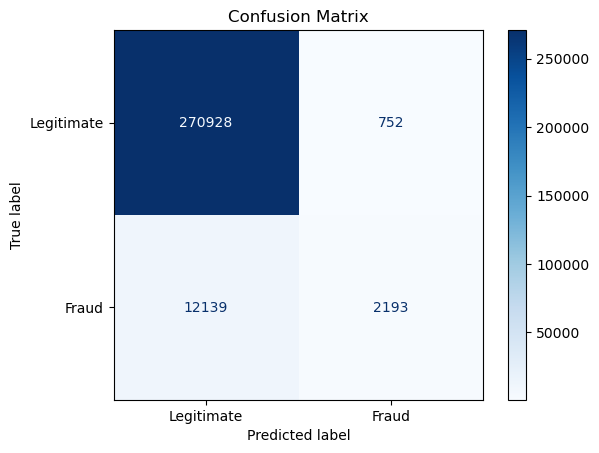

In [19]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Step 7 — Find the most important features

One of the best things about Random Forest is feature importance — it tells you which columns matter most for predicting fraud.

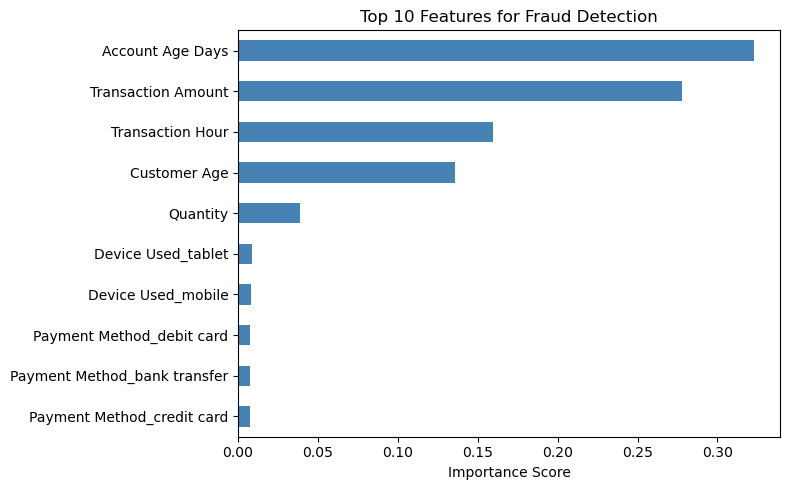

In [20]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Top 10 Features for Fraud Detection')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()